In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

In [9]:
print(df.shape)

df.head()

(32537, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [12]:
import pandas as pd

df = pd.read_csv("cleaned_adult.csv")

print(df.shape)

df.head()

(32537, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [11]:
X = df.drop("income", axis=1)

y = df["income"]

print(X.shape)
print(y.shape)

(32537, 14)
(32537,)


In [13]:
X = df.drop("income", axis=1)
y = df["income"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(32537, 100)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(26029, 100)
(6508, 100)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train_scaled, y_train)

train_pred = tree.predict(X_train_scaled)
test_pred = tree.predict(X_test_scaled)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy :", test_acc)

Training Accuracy: 1.0
Testing Accuracy : 0.8119237861094039


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree2 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

tree2.fit(X_train_scaled, y_train)

train_pred2 = tree2.predict(X_train_scaled)
test_pred2 = tree2.predict(X_test_scaled)

train_acc2 = accuracy_score(y_train, train_pred2)
test_acc2 = accuracy_score(y_test, test_pred2)

print("Training Accuracy:", train_acc2)
print("Testing Accuracy :", test_acc2)

Training Accuracy: 0.8533174536094357
Testing Accuracy : 0.8486478180700676


In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Gini Tree
gini_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

gini_tree.fit(X_train_scaled, y_train)

gini_pred = gini_tree.predict(X_test_scaled)

gini_acc = accuracy_score(y_test, gini_pred)

# Entropy Tree
entropy_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

entropy_tree.fit(X_train_scaled, y_train)

entropy_pred = entropy_tree.predict(X_test_scaled)

entropy_acc = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy :", gini_acc)
print("Entropy Accuracy :", entropy_acc)

Gini Accuracy : 0.848340503995083
Entropy Accuracy : 0.8440381069452981


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, rf_pred)
auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", accuracy)
print("Random Forest ROC-AUC:", auc)

Random Forest Accuracy: 0.8551014136447449
Random Forest ROC-AUC: 0.9054078792448154


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(5))

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

                              Feature  Importance
3                        capital.gain    0.169898
30  marital.status_Married-civ-spouse    0.163583
2                       education.num    0.116797
32       marital.status_Never-married    0.073371
0                                 age    0.070328


In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

gb_train_pred = gb.predict(X_train_scaled)
gb_test_pred = gb.predict(X_test_scaled)

gb_train_acc = accuracy_score(y_train, gb_train_pred)

gb_prob = gb.predict_proba(X_test_scaled)[:, 1]
gb_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting Training Accuracy:", gb_train_acc)
print("Gradient Boosting ROC-AUC:", gb_auc)

Gradient Boosting Training Accuracy: 0.8709900495601061
Gradient Boosting ROC-AUC: 0.9137610509790961


In [24]:
# Bottom 5 least important features
least5 = feature_importance.tail(5)["Feature"].tolist()

print("Least Important Features:")
print(least5)

# Remove them
X2 = X.drop(columns=least5)

# Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler2 = StandardScaler()

X_train2 = scaler2.fit_transform(X_train2)
X_test2 = scaler2.transform(X_test2)

# Random Forest
rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf2.fit(X_train2, y_train2)

prob2 = rf2.predict_proba(X_test2)[:,1]

auc2 = roc_auc_score(y_test2, prob2)

print("Original RF AUC :", auc)
print("Reduced RF AUC :", auc2)

Least Important Features:
['native.country_Honduras', 'native.country_Outlying-US(Guam-USVI-etc)', 'occupation_Armed-Forces', 'workclass_Never-worked', 'native.country_Holand-Netherlands']
Original RF AUC : 0.9054078792448154
Reduced RF AUC : 0.9052065474469139


In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Controlled Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print(name)
    print("Mean AUC :", scores.mean())
    print("Std AUC  :", scores.std())
    print("--------------------------")

    results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Mean AUC",
        "Std AUC"
    ]
)

cv_results.to_csv(
    "cv_results.csv",
    index=False
)

cv_results

Logistic Regression
Mean AUC : 0.9060068090283966
Std AUC  : 0.0032360483994591602
--------------------------
Controlled Decision Tree
Mean AUC : 0.8859167803711087
Std AUC  : 0.004166244880995228
--------------------------
Random Forest
Mean AUC : 0.9121063379240489
Std AUC  : 0.00331199757608858
--------------------------
Gradient Boosting
Mean AUC : 0.921567100807831
Std AUC  : 0.003915491877308408
--------------------------


,Model,Mean AUC,Std AUC
0,Logistic Regression,0.906007,0.003236
1,Controlled Decision Tree,0.885917,0.004166
2,Random Forest,0.912106,0.003312
3,Gradient Boosting,0.921567,0.003915


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X, y)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV Score:")
print(grid.best_score_)

print("\nTotal Configurations Tested:")
print(len(grid.cv_results_["params"]))

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV Score:
0.8860661902491895

Total Configurations Tested:
12


In [27]:
from sklearn.metrics import roc_auc_score
import pandas as pd

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

learning_results = []

for frac in fractions:

    n = int(len(X_train) * frac)

    X_small = X_train[:n]
    y_small = y_train[:n]

    best_pipeline = grid.best_estimator_

    best_pipeline.fit(X_small, y_small)

    train_prob = best_pipeline.predict_proba(X_small)[:,1]
    test_prob = best_pipeline.predict_proba(X_test)[:,1]

    train_auc = roc_auc_score(y_small, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    learning_results.append([
        frac,
        train_auc,
        test_auc
    ])

learning_curve = pd.DataFrame(
    learning_results,
    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]
)

print(learning_curve)

learning_curve.to_csv(
    "learning_curve.csv",
    index=False
)

   Training Fraction  Training AUC  Test AUC
0                0.2      0.949226  0.904341
1                0.4      0.937951  0.904563
2                0.6      0.933425  0.904741
3                0.8      0.930119  0.906202
4                1.0      0.928104  0.905855


In [28]:
import joblib

best_pipeline = grid.best_estimator_

joblib.dump(
    best_pipeline,
    "best_model.pkl"
)

print("best_model.pkl saved successfully.")

best_model.pkl saved successfully.


In [29]:
import joblib
import pandas as pd

loaded_model = joblib.load(
    "best_model.pkl"
)

sample = X.head(2)

prediction = loaded_model.predict(sample)

print("Predictions:")

print(prediction)

Predictions:
['<=50K' '<=50K']


In [31]:
cv_results.to_csv(
    "cv_results.csv",
    index=False
)

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

learning_curve.to_csv(
    "learning_curve.csv",
    index=False
)

print("All result files saved.")

All result files saved.


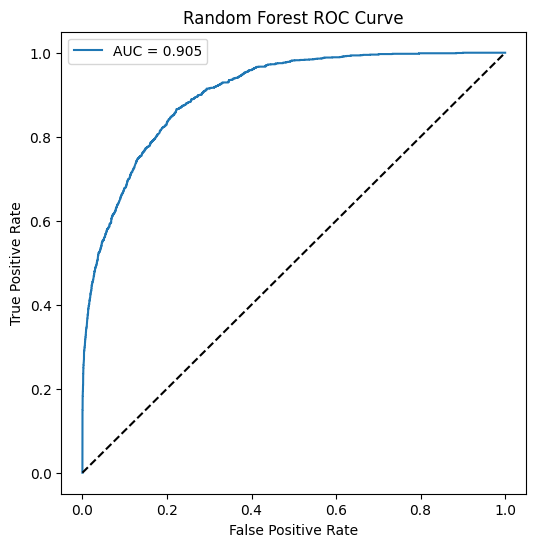

In [33]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Specify the positive label explicitly
fpr, tpr, thresholds = roc_curve(y_test, rf_prob, pos_label=">50K")

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

In [34]:
summary = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "CV Mean AUC":[
        0.906007,
        0.885917,
        0.912106,
        0.921567
    ]
})

summary

,Model,CV Mean AUC
0,Logistic Regression,0.906007
1,Decision Tree,0.885917
2,Random Forest,0.912106
3,Gradient Boosting,0.921567
